In [13]:
# Importação das bibliotecas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [14]:
df = pd.read_csv('data_balanceado_sem_pre_diabetes.csv')
df

,Diabetes_012,HighBP,HighChol,BMI,Smoker,PhysActivity,Fruits,Veggies,GenHlth,Sex,Age
0,1.0,1.0,1.0,29.0,0.0,1.0,0.0,1.0,3.0,0.0,12.0
1,0.0,0.0,0.0,26.0,0.0,1.0,1.0,1.0,2.0,1.0,4.0
2,0.0,1.0,0.0,34.0,0.0,1.0,1.0,1.0,3.0,0.0,12.0
3,0.0,1.0,1.0,26.0,1.0,1.0,0.0,1.0,2.0,1.0,11.0
4,1.0,1.0,1.0,26.0,0.0,1.0,0.0,0.0,3.0,0.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...
42443,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,3.0,0.0,3.0
42444,0.0,1.0,0.0,32.0,1.0,1.0,1.0,1.0,3.0,0.0,11.0
42445,1.0,0.0,1.0,26.0,0.0,1.0,1.0,1.0,1.0,1.0,11.0
42446,0.0,0.0,0.0,20.0,1.0,1.0,1.0,1.0,2.0,0.0,8.0


In [15]:
X = df.iloc[:,1:].astype(int).values
y = df.iloc[:,0].astype(int).values
X, y

(array([[ 1,  1, 29, ...,  3,  0, 12],
        [ 0,  0, 26, ...,  2,  1,  4],
        [ 1,  0, 34, ...,  3,  0, 12],
        ...,
        [ 0,  1, 26, ...,  1,  1, 11],
        [ 0,  0, 20, ...,  2,  0,  8],
        [ 0,  1, 34, ...,  3,  0,  7]]),
 array([1, 0, 0, ..., 1, 0, 0]))

In [16]:
# Divisão da base de dados entre treinamento e teste. Usamos 30% para testar e 70% para treinar. Random_state = 0 para sempre obter a mesma divisão da base quando o código for executado
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X,y,
                                                                  test_size = 0.3,
                                                                  random_state = 42)

In [17]:
# Criação e treinamento do modelo
arvore = DecisionTreeClassifier(max_depth=7, min_samples_split=8, random_state=42)
arvore.fit(X_treinamento, y_treinamento)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,8
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
# Realizando a classificação
y_pred = arvore.predict(X_teste)

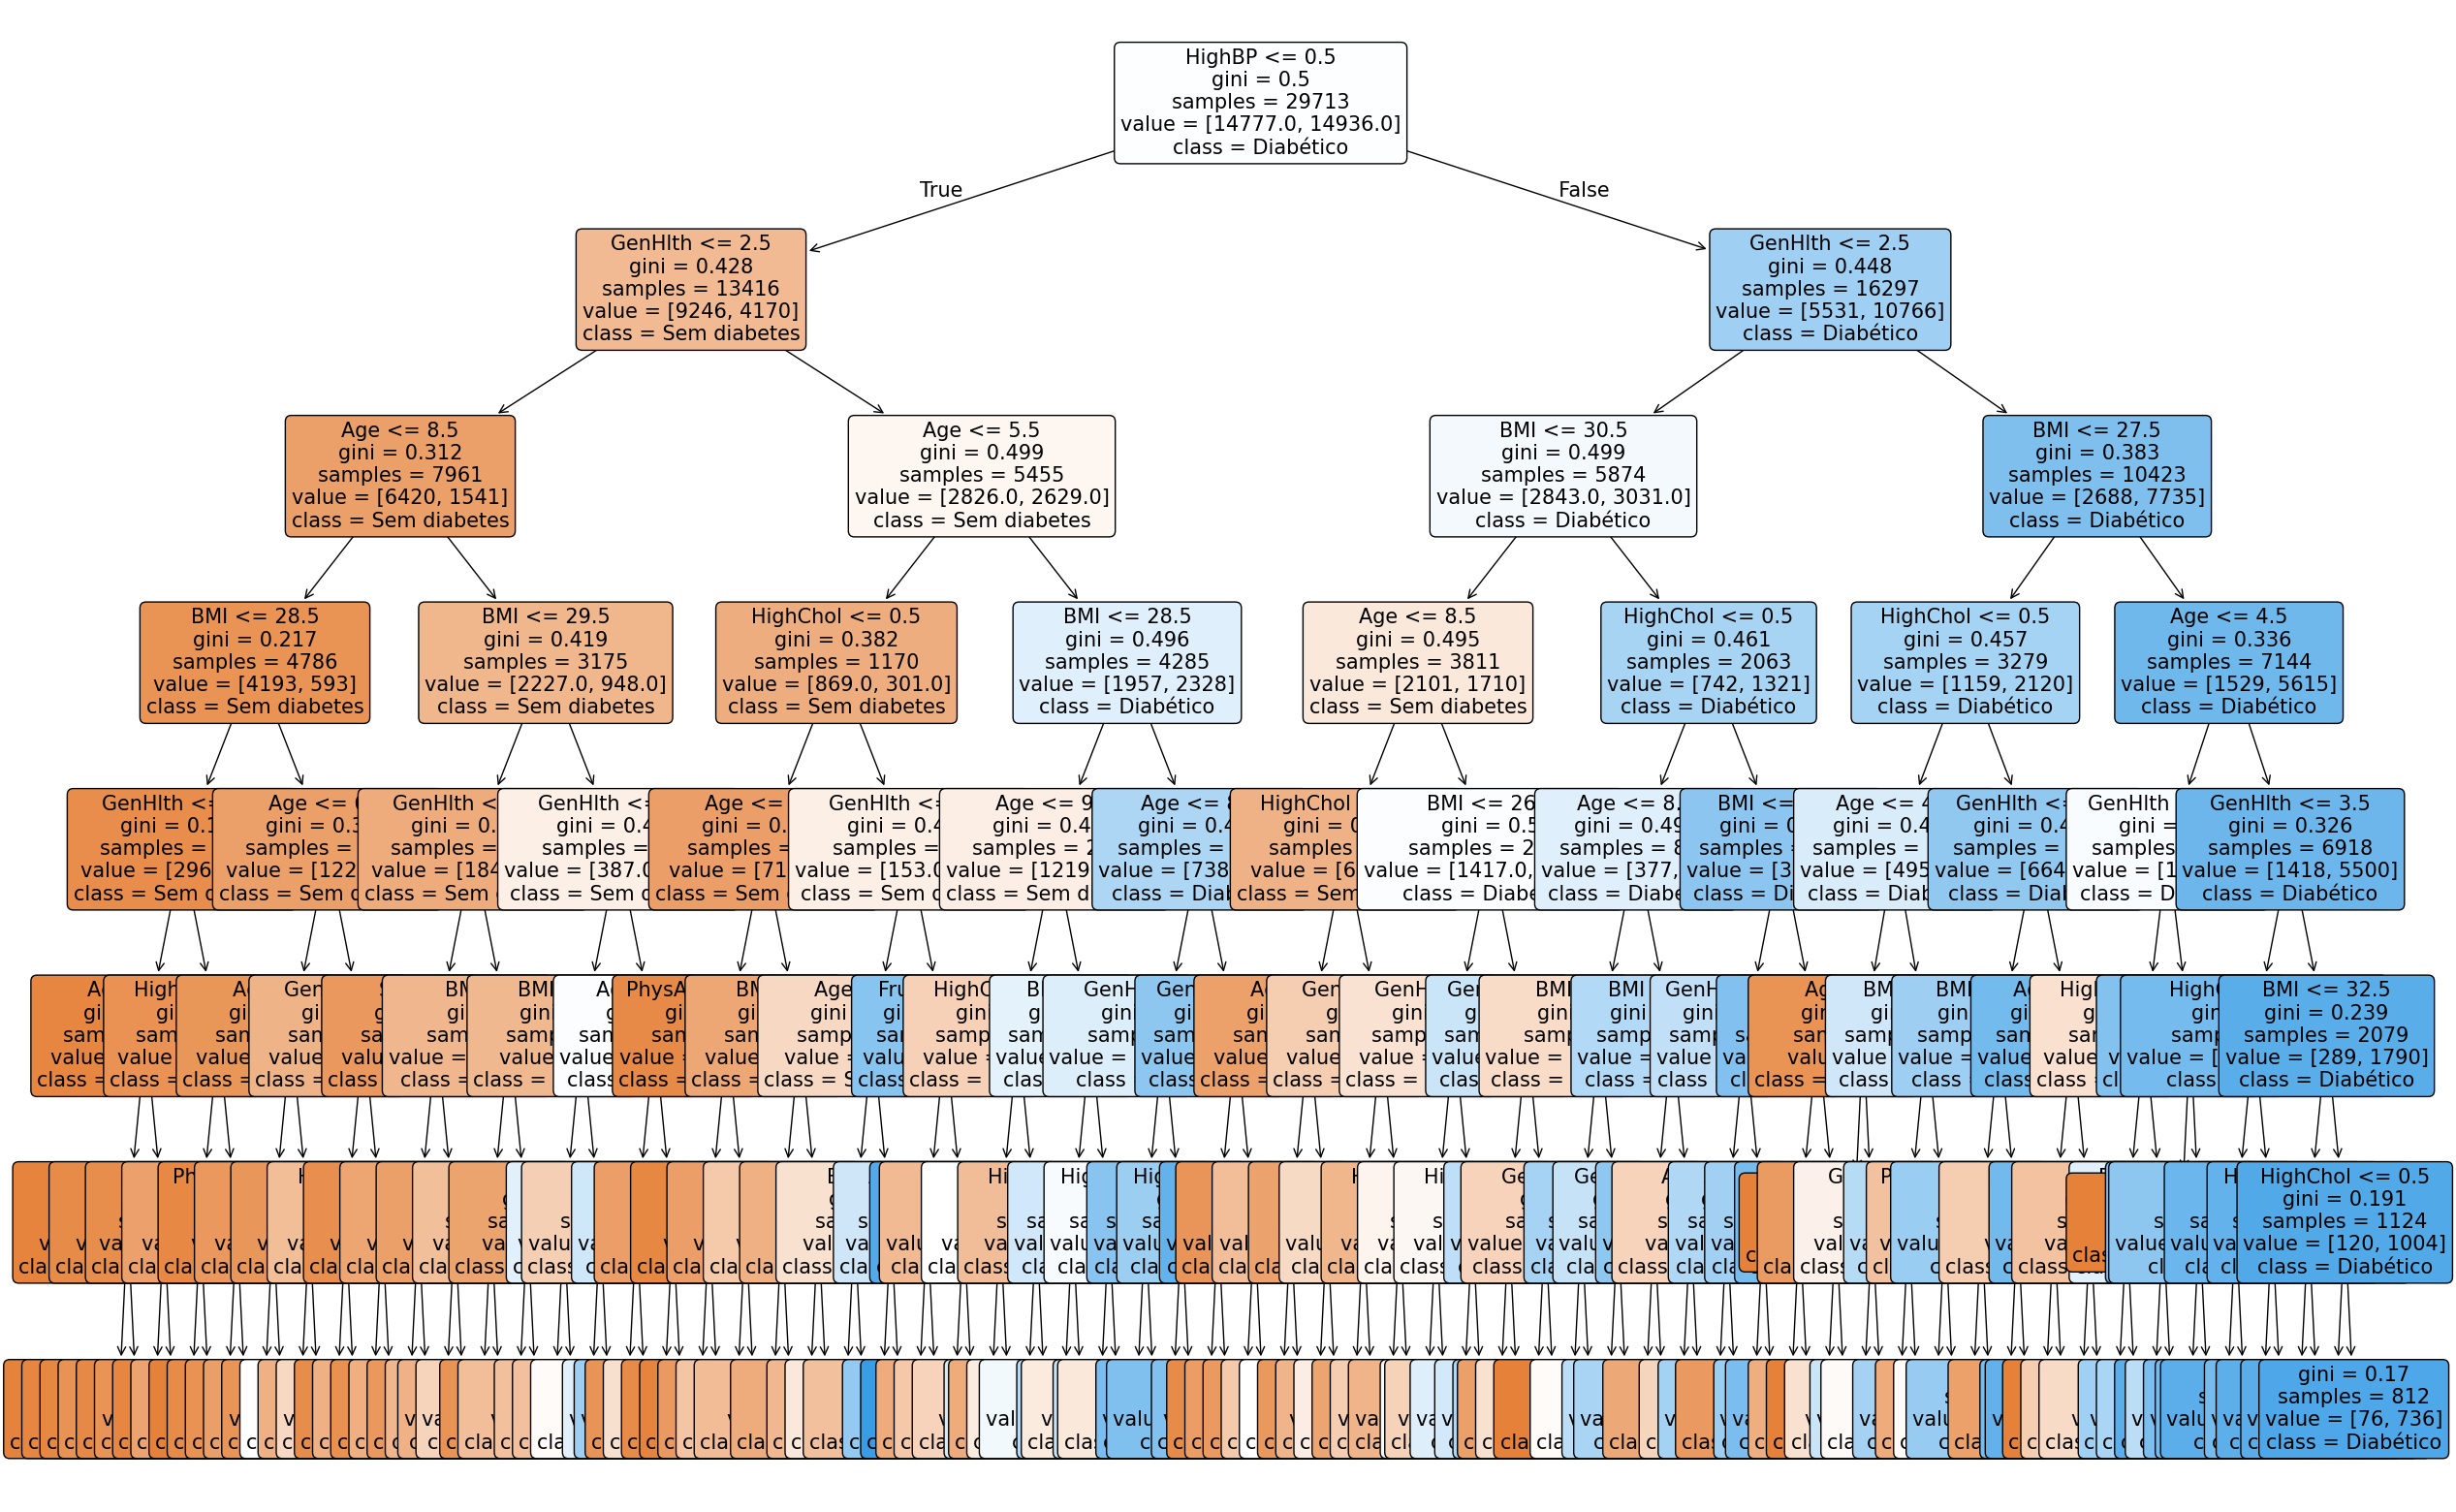

In [19]:
plt.figure(figsize=(30, 20))
tree.plot_tree(arvore, 
               filled=True, 
               feature_names=df.columns[1:], 
               class_names=['Sem diabetes', 'Diabético'], 
               rounded=True, 
               fontsize=15)
plt.show()

### MÉTRICAS

In [20]:
print("\nRelatório de Classificação:")
print(classification_report(y_teste, y_pred, digits=4))


Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.7655    0.6530    0.7048      6447
           1     0.6908    0.7948    0.7392      6288

    accuracy                         0.7230     12735
   macro avg     0.7281    0.7239    0.7220     12735
weighted avg     0.7286    0.7230    0.7218     12735



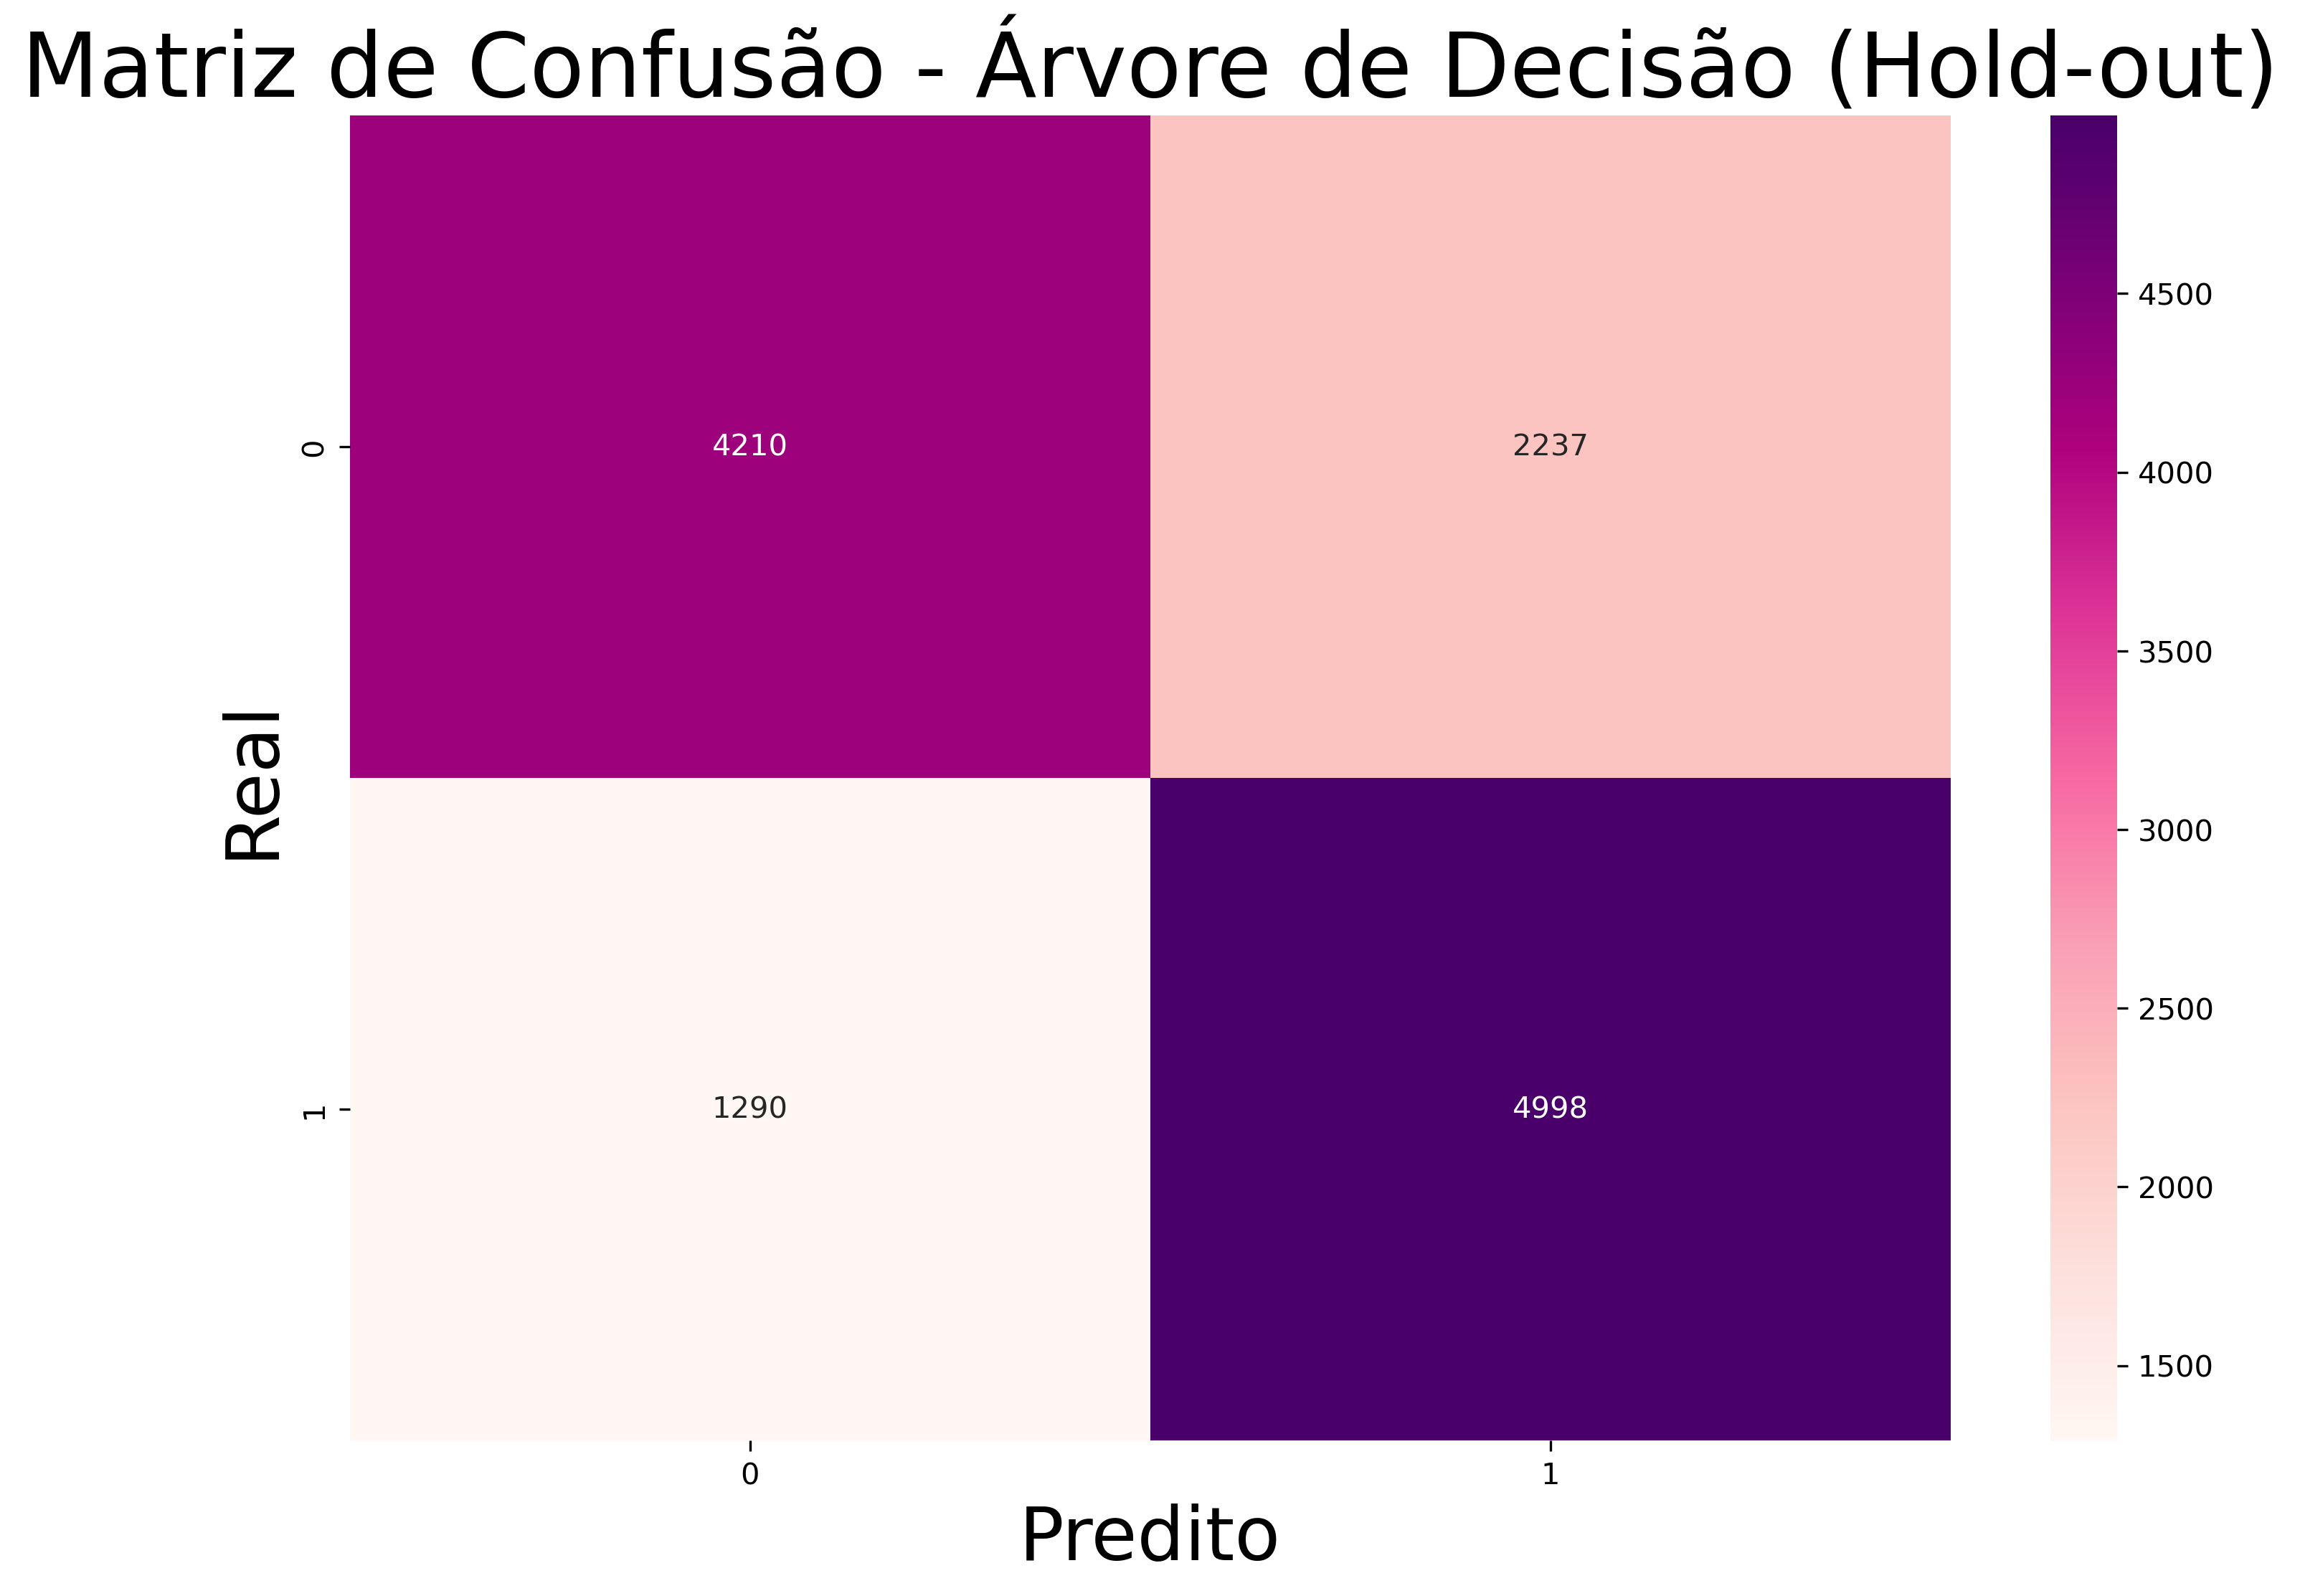

In [21]:
#matriz de confusão
confusao = confusion_matrix(y_teste, y_pred)
confusao

plt.figure(figsize=(12, 8), dpi=300)
sns.heatmap(confusao, annot=True, fmt="d", cmap="RdPu")
plt.xlabel("Predito",fontsize=25)
plt.ylabel("Real",fontsize =25)
plt.title("Matriz de Confusão - Árvore de Decisão (Hold-out)", fontsize=30)
plt.savefig("decision_tree_matriz_confusao_holdout.png", dpi=300)

In [22]:
#taxa acerto
taxa_acerto = accuracy_score(y_teste, y_pred)
taxa_acerto

0.7230467216332941

In [23]:
#taxa erro
taxa_erro = 1 - taxa_acerto
taxa_erro

0.2769532783667059

### CURVA ROC

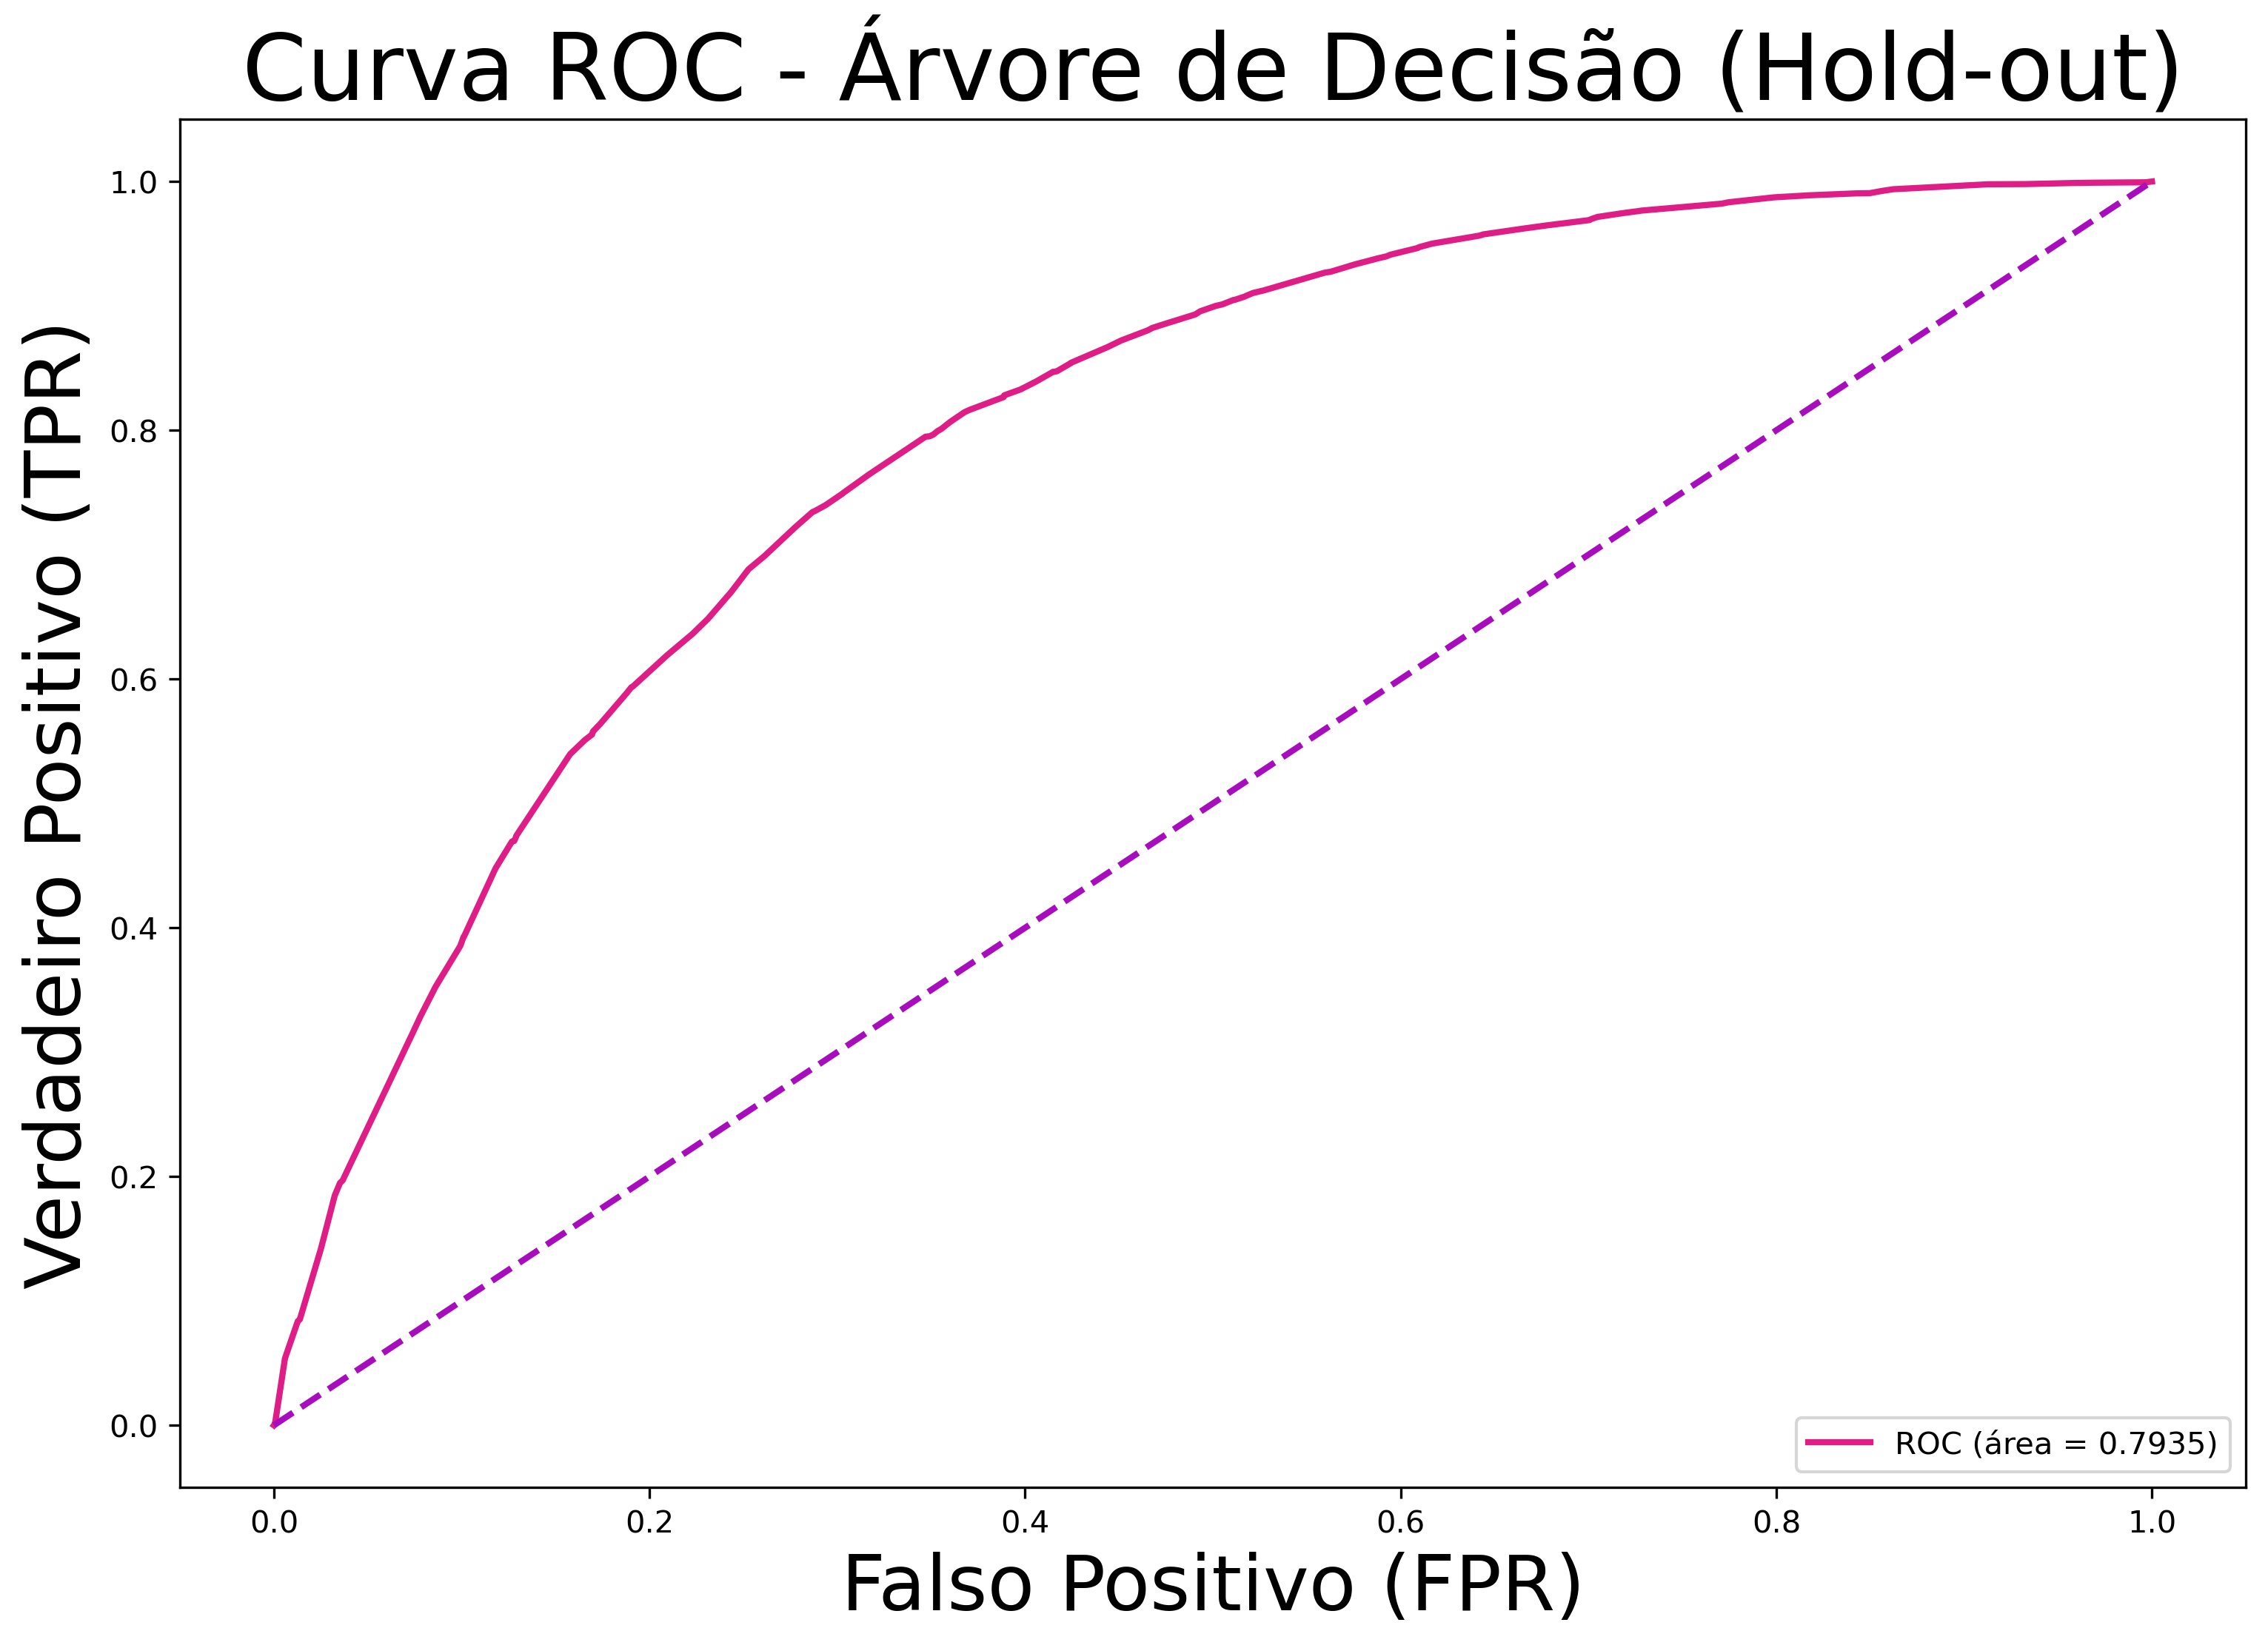

In [24]:
# Probabilidades previstas para a classe positiva (1) -> diabético
y_prob = arvore.predict_proba(X_teste)[:, 1]

# Calcula FPR, TPR e thresholds
fpr, tpr, thresholds = roc_curve(y_teste, y_prob)

# Calcula a área sob a curva (AUC)
roc_auc = auc(fpr, tpr)

# Plotando a curva ROC
plt.figure(figsize=(12, 8), dpi=300)
plt.plot(fpr, tpr, color='#de1d87', lw=2, label=f'ROC (área = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#a80dbd', lw=2, linestyle='--')  # linha de referência
plt.xlabel('Falso Positivo (FPR)', fontsize=25)
plt.ylabel('Verdadeiro Positivo (TPR)', fontsize=25)
plt.title('Curva ROC - Árvore de Decisão (Hold-out)', fontsize=30)
plt.legend(loc="lower right")
plt.savefig("decision_tree_curva_roc_holdout.png", dpi=300)
